In [52]:
import numpy as np
import pandas as pd
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
# Prophet
from prophet import Prophet
# ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [53]:
def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))


In [54]:
print("Leser data ...")
train = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/bysykkel_train.csv", parse_dates=["ds"])
test = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/test_compete.csv", parse_dates=["ds"])
test_truth=pd.read_csv("test_target_secret.csv", parse_dates=["ds"])
train = train.sort_values("ds")
test = test.sort_values("ds")
test_truth=test_truth.sort_values("ds")
print("done!")

Leser data ...
done!


In [55]:
#a_train = train.set_index("ds").asfreq("3h")
#a_test = test.set_index("ds").asfreq("3h")
#a_test_truth = test_truth.set_index("ds").asfreq("3h")

In [56]:
#print(a_train["y"].isna().sum())

In [57]:
#train["y"] = train["y"].interpolate()

In [58]:
#print(a_train["y"].isna().sum())

In [59]:
#a_train.dropna(inplace=True)
#a_test.dropna(inplace=True)
#a_test_truth.dropna(inplace=True)

In [60]:
# Prophet krev kolonnene ds og y
prophet_train = train[["ds", "y"]].copy()

model_prophet = Prophet()
model_prophet.fit(prophet_train)

# Lag future dataframe med same datoar som test
future = test[["ds"]].copy()

forecast = model_prophet.predict(future)

prophet_pred = forecast["yhat"].values

rmse_prophet = rmse(test_truth["y"].values, prophet_pred)

print("Prophet RMSE:", rmse_prophet)


12:07:56 - cmdstanpy - INFO - Chain [1] start processing
12:08:08 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 46.80907219165503


In [61]:
import pmdarima as pm

# Assuming 'train_data' is your 3-hour interval time series
#auto_model = pm.auto_arima(
#    train["y"], 
#    seasonal=True,       # Enable SARIMA
#    m=8,                # Daily cycle (24h / 3h = 8)
#    start_p=1, max_p=10, # Non-seasonal AR range
#    start_q=1, max_q=10, # Non-seasonal MA range
#    d=None,             # Let auto_arima test for differencing
#    test='adf',         # Use Augmented Dickey-Fuller test for 'd'
#    trace=True,         # Print progress as it searches
#    error_action='ignore',  
#    suppress_warnings=True, 
#    stepwise=True       # Uses a faster search algorithm
#)

In [62]:
#                                       SARIMAX Results                                        
#==============================================================================================
#Dep. Variable:                                      y   No. Observations:                12393
#Model:             SARIMAX(3, 0, 1)x(2, 0, [1, 2], 8)   Log Likelihood              -68698.046
#Date:                                Mon, 23 Feb 2026   AIC                         137416.091
#Time:                                        10:07:18   BIC                         137490.340
#Sample:                                             0   HQIC                        137440.958
#                                              - 12393                                         
#Covariance Type:                                  opg                                         
#==============================================================================
#                 coef    std err          z      P>|z|      [0.025      0.975]
#------------------------------------------------------------------------------
#intercept     39.0510      1.537     25.409      0.000      36.039      42.063
#ar.L1         -0.2980      0.008    -39.635      0.000      -0.313      -0.283
#ar.L2          0.5618      0.007     83.164      0.000       0.549       0.575
#ar.L3          0.2519      0.006     45.384      0.000       0.241       0.263
#ma.L1          0.9249      0.004    259.318      0.000       0.918       0.932
#ar.S.L8        1.2247      0.003    458.832      0.000       1.219       1.230
#ar.S.L16      -0.9652      0.003   -322.127      0.000      -0.971      -0.959
#ma.S.L8       -0.9929      0.005   -189.167      0.000      -1.003      -0.983
#ma.S.L16       0.7044      0.005    129.687      0.000       0.694       0.715
#sigma2      3827.9961     31.356    122.081      0.000    3766.539    3889.453
#===================================================================================
#Ljung-Box (L1) (Q):                   3.42   Jarque-Bera (JB):             13581.04
#Prob(Q):                              0.06   Prob(JB):                         0.00
#Heteroskedasticity (H):               0.39   Skew:                             0.90
#Prob(H) (two-sided):                  0.00   Kurtosis:                         7.80
#===================================================================================

#Warnings:
#[1] Covariance matrix calculated using the outer product of gradients (complex-step).

In [63]:
# Print the found best parameters
#print(auto_model.summary())

In [64]:
#auto_model.plot_diagnostics(figsize=(10, 8))
#plt.show()

In [65]:
#auto_forecast=auto_model.forecast(steps=len(test))
#rmse_auto = rmse(test_truth["y"].values, auto_forecast)

In [85]:
order = (3, 1, 7)            # (p, d, q)
seasonal_order = (2, 1, [1,2], 8) # (P, D, Q, s)

sarima_model = SARIMAX(
    train["y"],
    order=order, 
    seasonal_order=seasonal_order, 
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=len(test))

rmse_sarima = rmse(test_truth["y"].values, sarima_forecast)

print("SARIMA RMSE:", rmse_sarima)

C:\Users\jens.nilsen\python\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA RMSE: 98.80334106818138


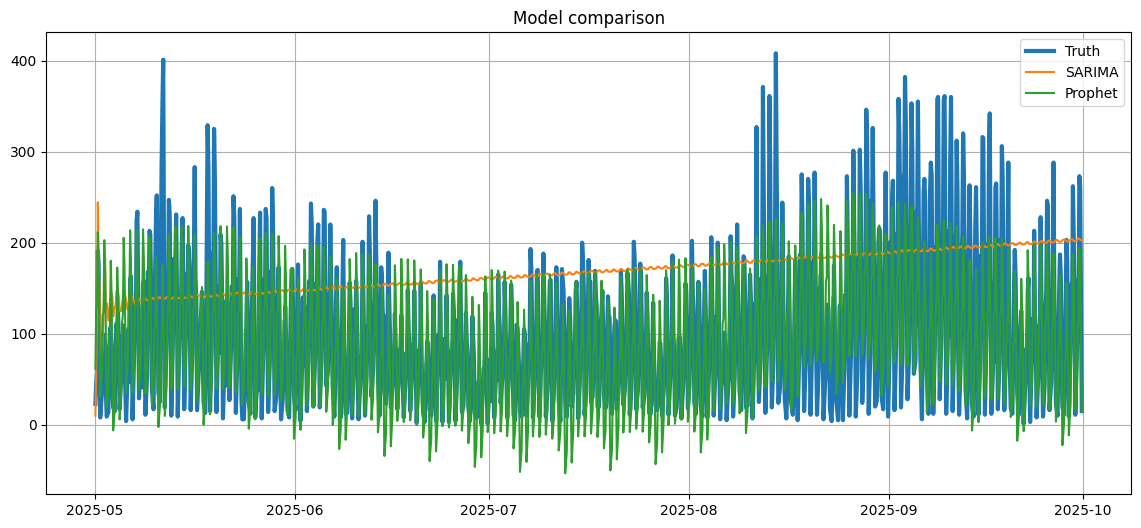

In [86]:
plt.figure(figsize=(14,6))

plt.plot(test["ds"], test_truth["y"], label="Truth", linewidth=3)
plt.plot(test["ds"], sarima_forecast, label="SARIMA")
#plt.plot(test["ds"], model, label="auto_arima")
plt.plot(test["ds"], prophet_pred, label="Prophet")

plt.title("Model comparison")
plt.legend()
plt.grid(True)
plt.show()


In [68]:
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)


In [69]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train[["y"]])

window = 24  # 24 tidssteg tilbake

X_train, y_train = create_sequences(scaled_train, window)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

In [70]:
#model_lstm = Sequential([
#    LSTM(50, activation='tanh', input_shape=(window, 1)),
#    Dense(1)
#])

#model_lstm.compile(optimizer='adam', loss='mse')

#model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

In [71]:
#history = scaled_train[-window:].flatten().tolist()
#predictions = []

#for _ in range(len(test)):
#    x_input = np.array(history[-window:]).reshape((1, window, 1))
#    yhat = model_lstm.predict(x_input, verbose=0)
#    predictions.append(yhat[0,0])
#    history.append(yhat[0,0])

# Skaler tilbake
#lstm_pred = scaler.inverse_transform(np.array(predictions).reshape(-1,1)).flatten()

#rmse_lstm = rmse(test_truth["y"].values, lstm_pred)

#print("LSTM RMSE:", rmse_lstm)